In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np

insurance = pd.read_csv("insurance.csv");

In [ ]:
insurance.head();

In [ ]:
insurance.info();

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [ ]:
insurance.describe();

In [ ]:
insurance['charges'].quantile(.995);

### Exploring The Target

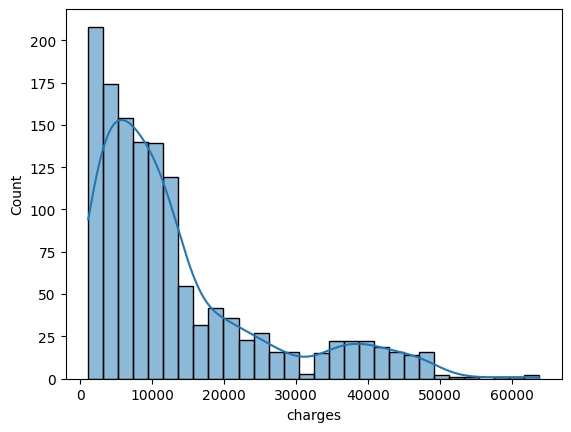

In [ ]:
sns.histplot(insurance['charges'], kde=True);

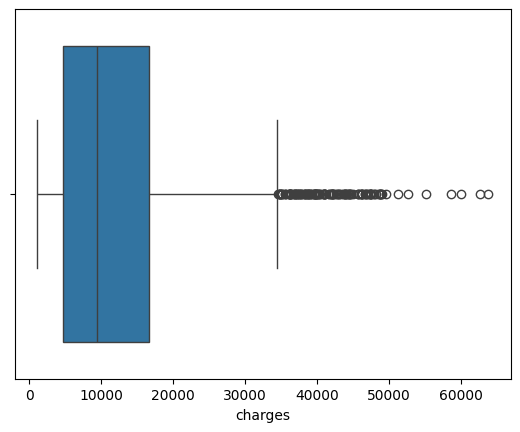

In [ ]:
sns.boxplot(x=insurance["charges"]);

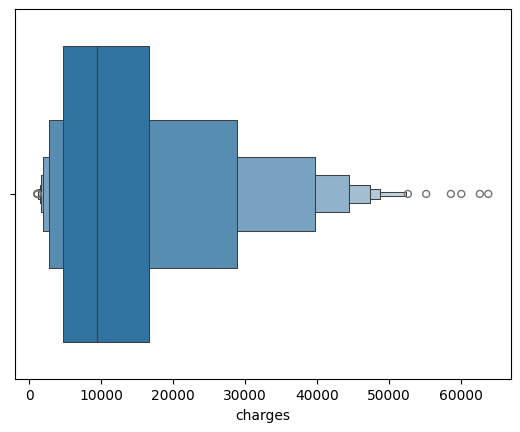

In [ ]:
sns.boxenplot(x=insurance["charges"]);

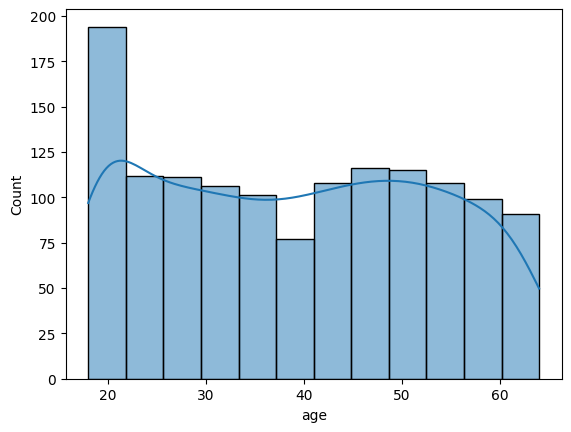

In [ ]:
sns.histplot(x=insurance["age"], kde=True);

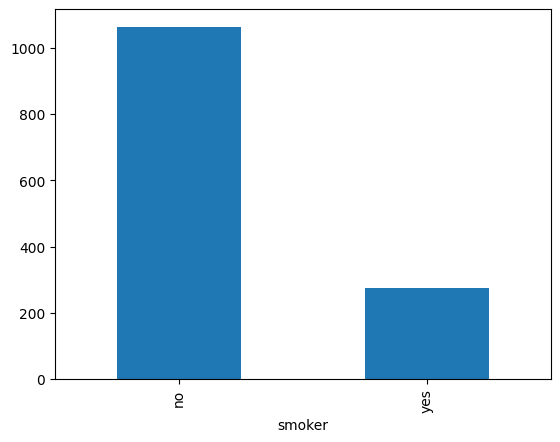

In [ ]:
insurance["smoker"].value_counts().plot.bar();

### Linear Relationship

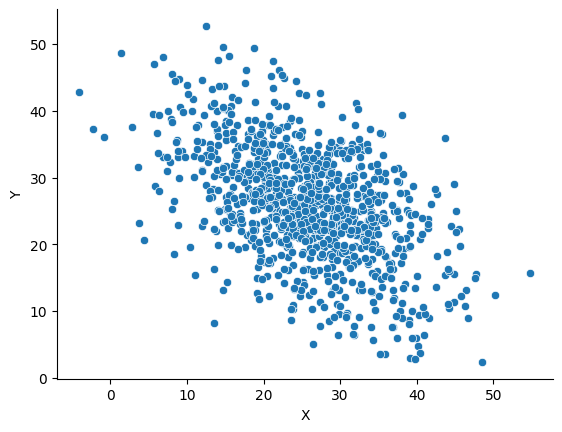

In [ ]:
xx = np.array([-0.51, 51.2])
yy = np.array([0.33, 51.6])
means = [xx.mean(), yy.mean()]  
stds = [xx.std() / 3, yy.std() / 3]
corr = -.5       # correlation
covs = [
    [stds[0]**2, stds[0]*stds[1]*corr], 
    [stds[0]*stds[1]*corr, stds[1]**2]
] 

m = np.random.multivariate_normal(means, covs, 1000).T

df = pd.DataFrame(m).T
df.columns = ["X", "Y"]
df.head()

sns.scatterplot(df, x="X", y="Y")

sns.despine()

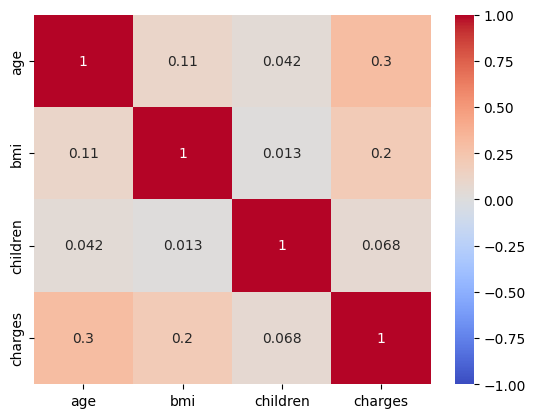

In [ ]:
sns.heatmap(insurance.corr(numeric_only=True), annot=True, vmin=-1, vmax=1, cmap="coolwarm");

### Feature - Target Relationship

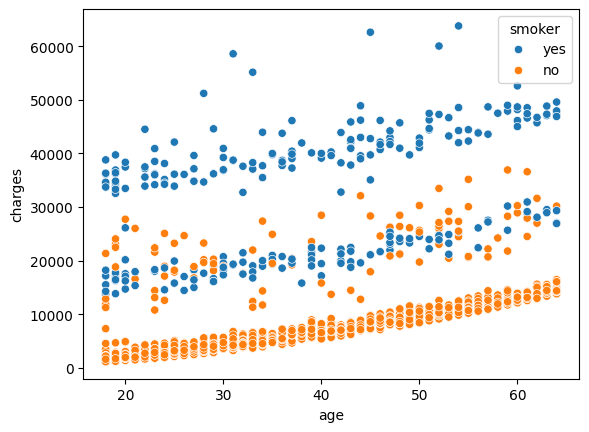

In [ ]:
sns.scatterplot(insurance, x="age", y="charges", hue="smoker" );

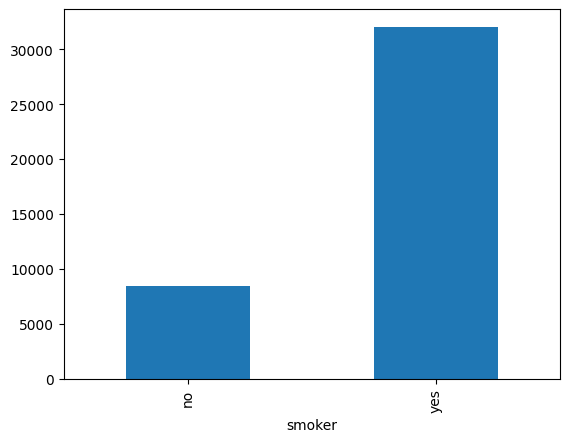

In [ ]:
insurance.groupby("smoker")["charges"].mean().plot.bar();

### Feature-Feature Relationship

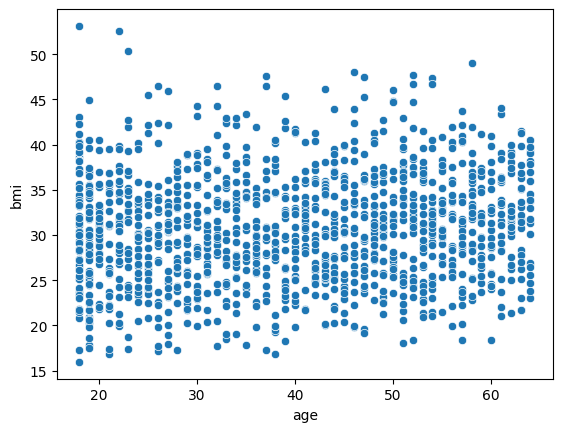

In [ ]:
sns.scatterplot(insurance, x="age", y="bmi");

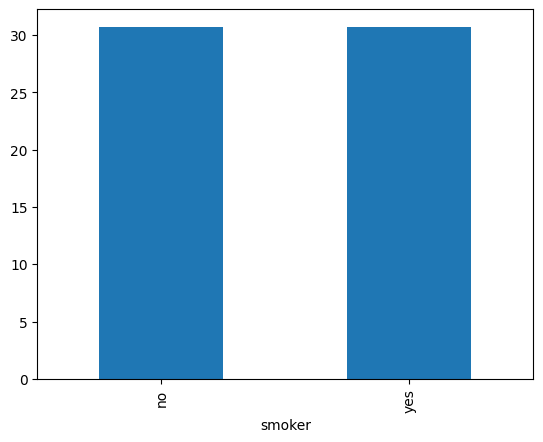

In [ ]:
insurance.groupby("smoker")["bmi"].mean().plot.bar();

### Pairplots & LMPlots

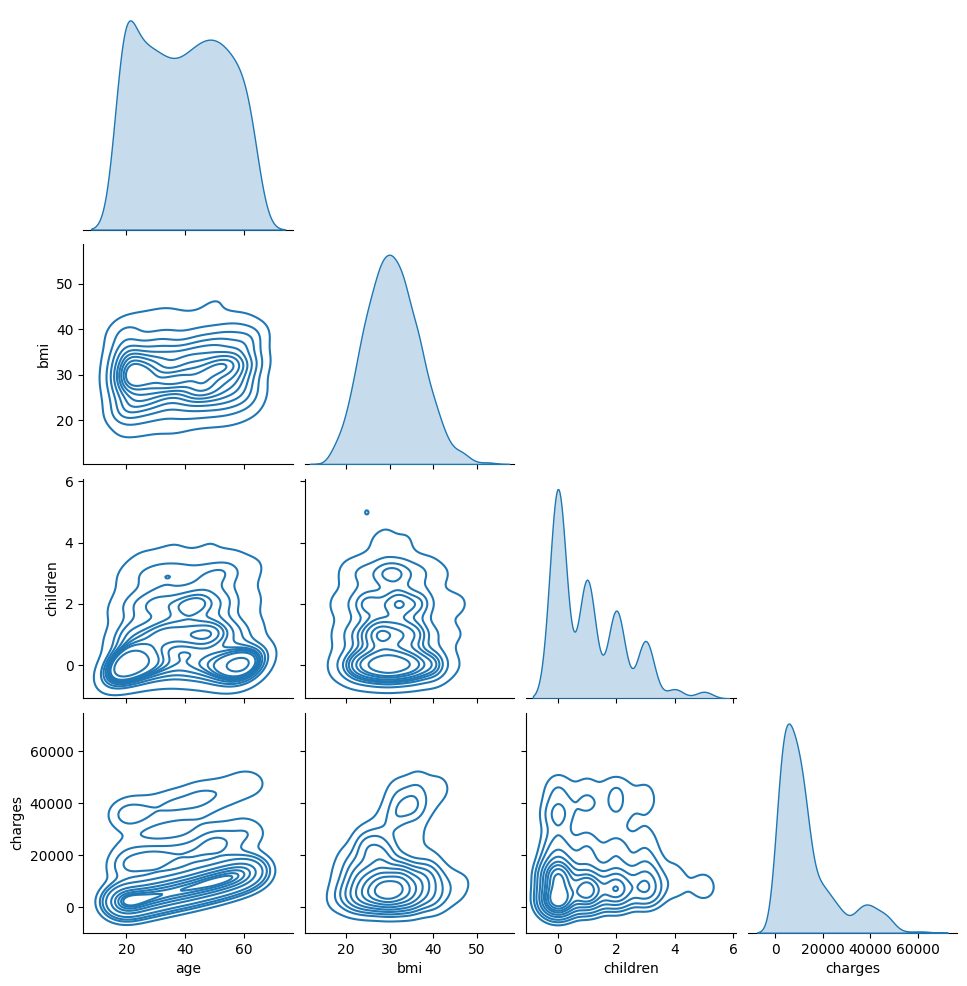

In [ ]:
sns.pairplot(insurance, corner=True, kind="kde");

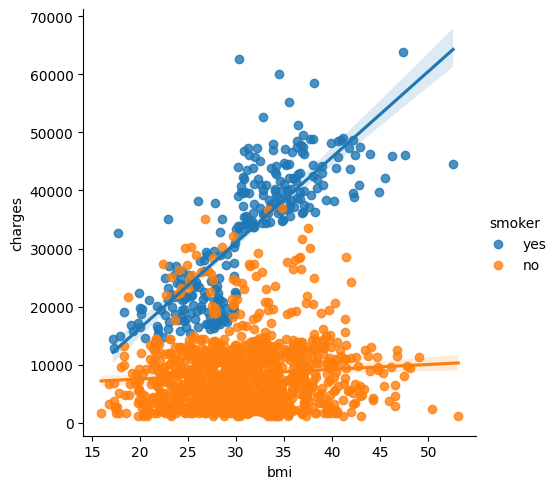

In [ ]:
sns.lmplot(insurance, x="bmi", y="charges", hue="smoker");